<img src="../images/logo_VORTEX.png" width="200" height="auto" alt="Company Logo">

# Chapter 8: Spatial and Temporal Wind Variability

_Overview_

A wind resource is usually quoted as one number: the mean wind speed. But the energy, the risk and the value of a project live in the **variability** around that mean — and that variability has **two dimensions**: space and time.

This notebook is the reproducible companion of the Vortex blog post *"A better view of variables variability (without eating your tongue)"*. From the `seasia` data pack (one year of half-hourly wind speed at 111 m at **four points** of a ~40 × 45 km mesoscale domain in Southeast Asia, plus the **annual-mean wind speed raster** of the whole domain — see [the datasets readme](../README_about_datasets.md)) we will:

1. Plot the **map** of annual-mean wind speed: spatial variability of the mean.
2. Look at the **raw series** at one point (a year, then ten days).
3. Compress that series into three **temporal summaries** — histogram, daily cycle, yearly cycle — each answering a different question.
4. Put the summaries **back on the map** at the four points: the temporal behaviour itself varies in space, well beyond the mean.

In [1]:
%matplotlib inline
# Import libraries and the chapter-8 helper functions
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../examples')
from example_8_Variability_functions import (
    read_four_points, read_points_meta, read_mean_ws_map,
    convert_index_to_local, daily_cycle, monthly_cycle,
    hour_month_table, variability_summary, plot_mean_ws_map,
    plot_map_with_insets, draw_histogram, draw_daily_cycle,
    draw_monthly_cycle,
)

SITE = 'seasia'
base_path = os.path.join(os.getcwd(), '../data', SITE)
UTC_OFFSET = 7.0   # Indochina Time
POINT = 'P3'       # try 'P1' (ridge) or 'P2' (valley) too

## 1. Read the data pack

Three files: the four half-hourly series (gzipped csv), the per-point metadata, and the mean wind speed raster (netCDF with **km offsets** instead of geographic coordinates — the pack is anonymised).

One classic pitfall before any cycle analysis: the timestamps are in **UTC**, but daily cycles are driven by the sun. We shift the index to **local time** (UTC+7) first — skip this and the diurnal peaks show up at the wrong hours.

In [2]:
df = read_four_points(os.path.join(base_path, 'four_points_ws.csv.gz'))
meta = read_points_meta(os.path.join(base_path, 'four_points_meta.csv'))
ds_map = read_mean_ws_map(os.path.join(base_path, 'mean_ws_map.nc'))

df_local = convert_index_to_local(df, utc_offset=UTC_OFFSET)
df_local.describe().round(2)

,P1,P2,P3,P4
count,17520.00,17520.00,17520.00,17520.00
mean,8.42,3.83,6.17,5.70
std,4.14,2.55,3.69,2.68
min,0.06,0.01,0.02,0.04
25%,5.08,1.56,3.46,3.61
50%,8.36,3.45,5.98,5.88
75%,11.68,5.80,8.07,7.78
max,19.85,13.18,23.58,18.15


In [3]:
meta

,tag,x_km,y_km,mean_ws,height_m
code,,,,,
P1,ridge,21.750,37.643,8.422,111.0
P2,valley,31.945,1.008,3.829,111.0
P3,median,8.157,9.411,6.167,111.0
P4,far,1.019,43.020,5.703,111.0


Four points of the *same* domain span **3.8 to 8.4 m/s** in annual mean. Keep that in mind — and now look at where they sit.

## 2. Spatial variability of the mean: the map

Within a distance you would drive in half an hour, the annual mean spans more than a factor of two. Since wind power scales with the cube of speed at moderate winds, siting a turbine on the wrong side of this map is not a small error.

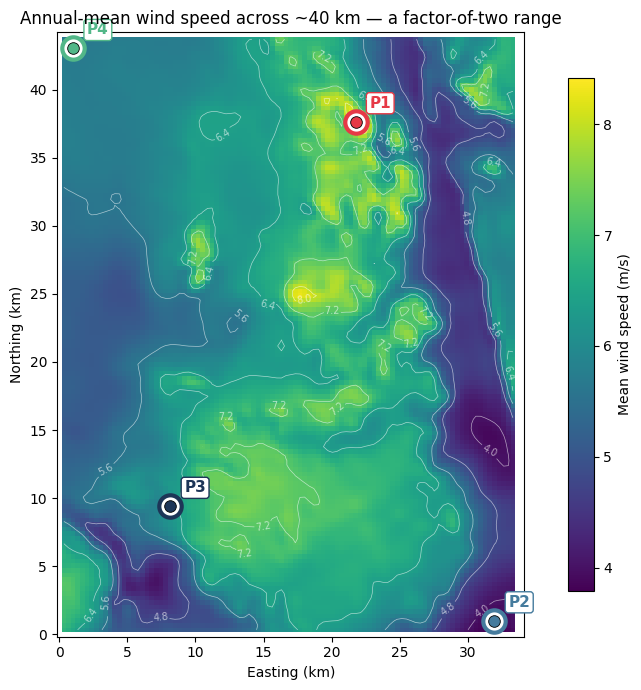

In [4]:
plot_mean_ws_map(ds_map, meta,
                 title='Annual-mean wind speed across ~40 km — '
                       'a factor-of-two range')

So far, so familiar — this is what wind atlases show. Hold that thought: the map of means is hiding as much as it reveals.

## 3. Temporal variability, raw: one year at one point

Stand at P3 and watch the wind instead of averaging it. The signal fluctuates on every timescale at once: half-hourly bursts, day-long episodes, week-long synoptic swings, and a seasonal tide. Zoom into ten days and a **daily rhythm** appears that the full-year view smears out.

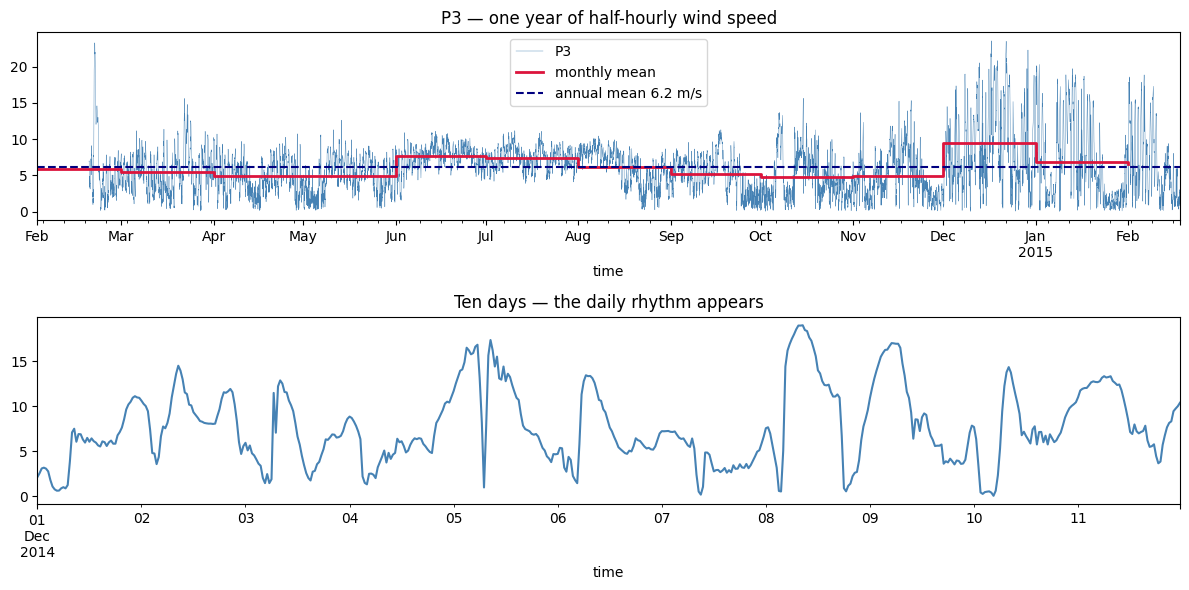

In [5]:
ws = df_local[POINT].dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
ws.plot(ax=axes[0], lw=0.3, color='steelblue')
ws.resample('MS').mean().plot(ax=axes[0], drawstyle='steps-post',
                              color='crimson', lw=2, label='monthly mean')
axes[0].axhline(ws.mean(), ls='--', color='navy',
                label=f'annual mean {ws.mean():.1f} m/s')
axes[0].legend()
axes[0].set_title(f'{POINT} — one year of half-hourly wind speed')
ws.loc['2014-12-01':'2014-12-11'].plot(ax=axes[1], color='steelblue')
axes[1].set_title('Ten days — the daily rhythm appears')
plt.tight_layout()
plt.show()

## 4. Three temporal summaries, three different questions

- The **histogram** (frequency per wind-speed bin) answers: *how often is the wind at each strength?* It is what energy integrals and Weibull fits are built on — and it deliberately forgets *when* anything happened.
- The **daily cycle** answers: *at what time of day does the energy arrive?* Crucial as soon as solar, storage or time-varying prices enter the project.
- The **yearly cycle** answers: *which months carry the year?* Here the monsoon concentrates the resource: the best month runs at about twice the worst.

None of these is "the" temporal variability — they are projections of the same series onto different axes.

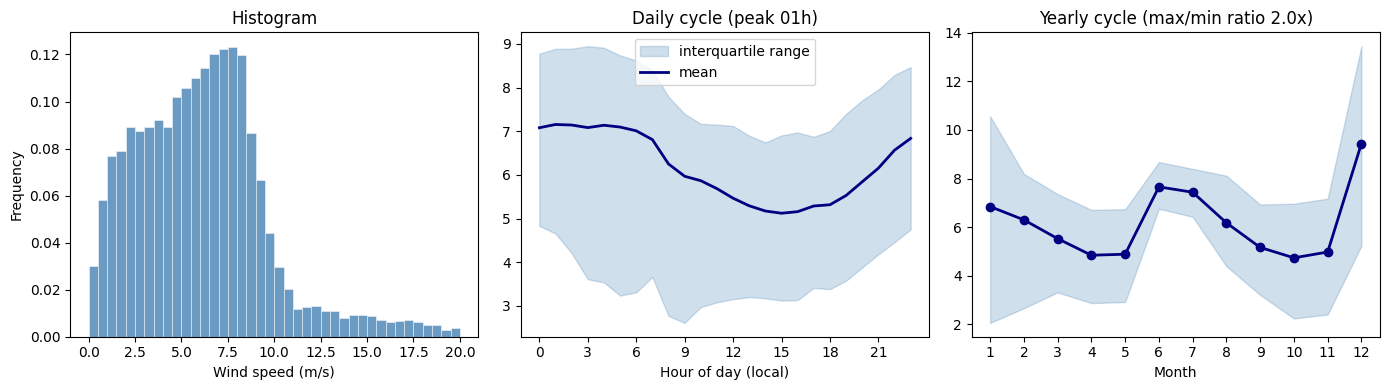

In [6]:
dc = daily_cycle(ws)
mc = monthly_cycle(ws)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 4))
ax0.hist(ws.values, bins=np.arange(0, 20.01, 0.5), density=True,
         color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
ax0.set_xlabel('Wind speed (m/s)')
ax0.set_ylabel('Frequency')
ax0.set_title('Histogram')

ax1.fill_between(dc.index, dc['q_lo'], dc['q_hi'], alpha=0.25,
                 color='steelblue', label='interquartile range')
ax1.plot(dc.index, dc['mean'], color='navy', lw=2, label='mean')
ax1.set_xticks(range(0, 24, 3))
ax1.set_xlabel('Hour of day (local)')
ax1.set_title(f"Daily cycle (peak {int(dc['mean'].idxmax()):02d}h)")
ax1.legend()

ax2.fill_between(mc.index, mc['q_lo'], mc['q_hi'], alpha=0.25,
                 color='steelblue')
ax2.plot(mc.index, mc['mean'], color='navy', lw=2, marker='o')
ax2.set_xticks(range(1, 13))
ax2.set_xlabel('Month')
ratio = mc['mean'].max() / mc['mean'].min()
ax2.set_title(f'Yearly cycle (max/min ratio {ratio:.1f}x)')
plt.tight_layout()
plt.show()

The two cycles also **interact**: the 12 × 24 table shows the daily rhythm changing strength (and even timing) with the season.

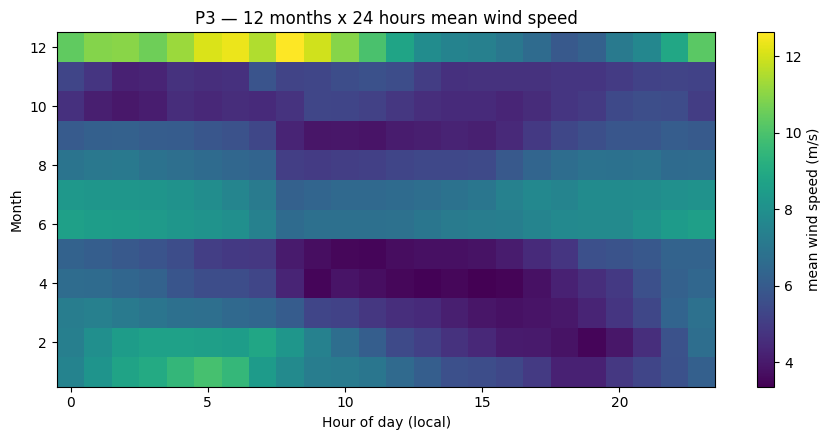

In [7]:
table = hour_month_table(ws)
fig, ax = plt.subplots(figsize=(9, 4.5))
mesh = ax.pcolormesh(table.columns, table.index, table.values,
                     cmap='viridis', shading='auto')
fig.colorbar(mesh, ax=ax, label='mean wind speed (m/s)')
ax.set_xlabel('Hour of day (local)')
ax.set_ylabel('Month')
ax.set_title(f'{POINT} — 12 months x 24 hours mean wind speed')
plt.tight_layout()
plt.show()

## 5. The map, revisited: spatial variability of everything else

Here is the step that usually goes missing. Each of those temporal summaries can be computed at *every* point of the map — and each one varies across the map as strongly as the mean does.

First the **histograms**: they do not just slide left or right with the mean — they change *shape*. The ridge point (P1) is broad and near-symmetric; the valley point (P2), 38 km away, is calm-heavy and long-tailed, spending 45 % of its life below 3 m/s.

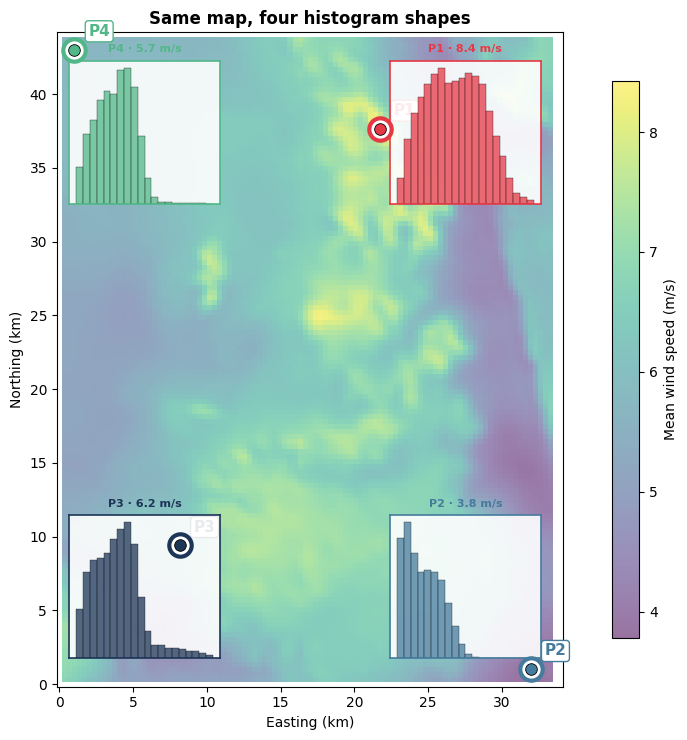

In [8]:
plot_map_with_insets(ds_map, meta, df_local, draw_histogram,
                     'Same map, four histogram shapes')

The **daily cycles** are not scaled copies either — P1 and P2 are in *opposite phase*: the ridge peaks around 2 am local, the valley at 6 pm. Same domain, same climate — one point generates at night what the other generates at dusk. For a hybrid wind–solar plant or a storage-backed PPA these are different products, not a windier and a calmer version of the same site.

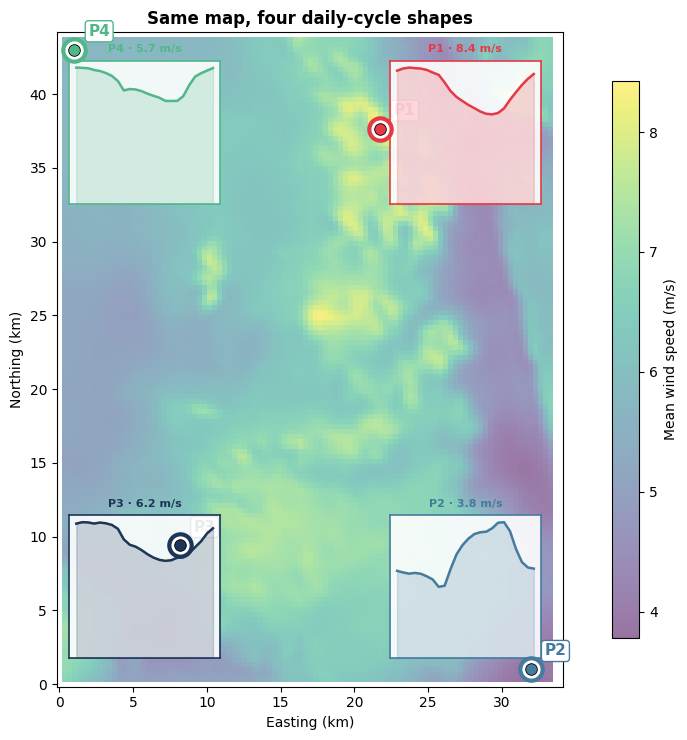

In [9]:
plot_map_with_insets(ds_map, meta, df_local, draw_daily_cycle,
                     'Same map, four daily-cycle shapes')

And the **yearly cycles** split the map a third way: the ridge rides the northeast monsoon (peak in December), the valley the southwest monsoon (peak in July). Note P3 vs P4: annual means within 0.5 m/s — near-twins on the mean map — yet opposite seasonal peaks. A portfolio mixing them would be seasonally hedged; the map of means contains no trace of that fact.

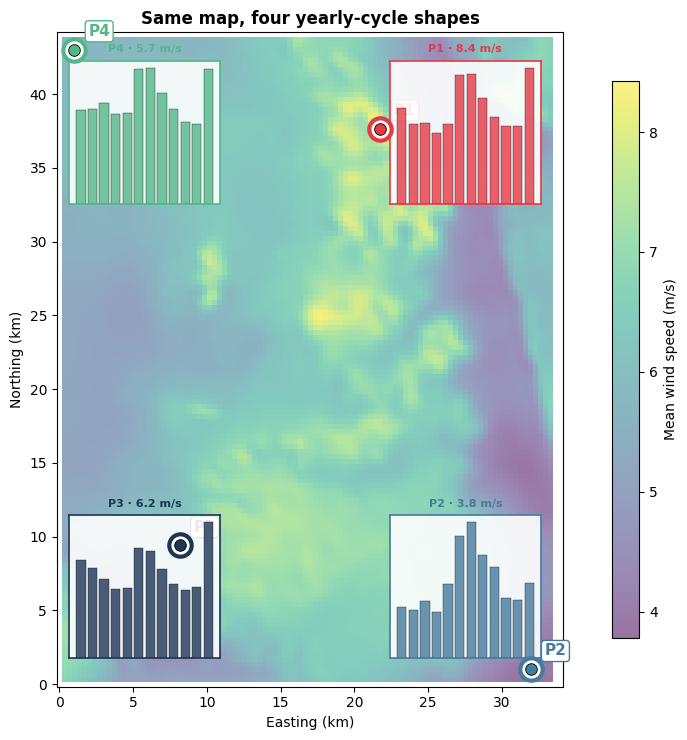

In [10]:
plot_map_with_insets(ds_map, meta, df_local, draw_monthly_cycle,
                     'Same map, four yearly-cycle shapes')

## 6. Summary

One line per point — mean, spread, percentiles, calm fraction, and the hour/month of the diurnal and seasonal maxima:

In [11]:
variability_summary(df_local)

,mean (m/s),std (m/s),P50 (m/s),P90 (m/s),calm <3 m/s (%),peak hour (local),peak month
P1,8.42,4.14,8.36,13.93,10.80,2.0,12.0
P2,3.83,2.55,3.45,7.41,44.75,18.0,7.0
P3,6.17,3.69,5.98,10.03,20.94,1.0,12.0
P4,5.70,2.68,5.88,9.04,18.85,0.0,7.0


### Wrap-up

1. **Variability is temporal *and* spatial.** Treating "the site" as one point and "the wind" as one number averages away both dimensions.
2. **Spatial variability goes far beyond the mean map.** Distribution shape, diurnal phase and seasonal timing all vary from cell to cell — here, into outright opposition within one domain.
3. **Temporal variability has several faces**, each feeding a different decision: the histogram → the energy integral; the daily cycle → hybridisation and price capture; the yearly cycle → seasonal adequacy and portfolio balance. Keep the series and derive them all.